# 🌍 Inversión 1D de Datos Magnetotelúricos
---
**Curso:** Magnetotelúrica desde Cero  
**Módulo 3 — Análisis e Interpretación de Datos MT**

En este notebook se realiza la **inversión 1D** de un sondeo MT usando
el framework **SimPEG**. La inversión 1D asume que el subsuelo varía
únicamente en profundidad (modelo de capas horizontales).

### Objetivos
1. Entender el problema inverso MT y sus componentes (SimPEG).
2. Configurar la malla, la simulación y los parámetros de inversión.
3. Analizar la convergencia con la **curva de Tikhonov**.
4. Visualizar e interpretar el modelo de resistividad resultante.

> **Prerequisito:** Notebooks Preprocesamiento y Análisis completados; `h5_procesado/collection_procesado_interpolado.h5` disponible.

<div style="background:#f4f0fb;border:1px solid #8E44AD;border-radius:6px;padding:12px 16px;margin:10px 0"><b>🧠 El Problema Inverso MT</b><br>Dado un conjunto de datos observados <b>d<sub>obs</sub></b> (ρ<sub>a</sub> y φ), la inversión busca el modelo <b>m</b> (resistividad vs. profundidad) que los reproduce. El funcional a minimizar es:<br><b>φ(m) = φ<sub>d</sub>(m) + β·φ<sub>m</sub>(m)</b><br>donde φ<sub>d</sub> es el desajuste de datos, φ<sub>m</sub> es la regularización del modelo, y β es el parámetro de compensación que pondera ambos términos. SimPEG ajusta β automáticamente durante las iteraciones con el esquema de <b>enfriamiento de Tikhonov</b>.</div>

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 1 · Importar librerías</span></div>

In [2]:
# Importar librerías

import numpy as np
from copy import deepcopy
from pathlib import Path
import pandas as pd
import inspect
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec

#MTpy
from mtpy import MT, MTCollection, MTData

#SimPEG
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
from simpeg import (
    maps,
    data,
    data_misfit, 
    regularization,
    optimization,
    inverse_problem,
    inversion, 
    directives,
    utils,
)

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 2 · Cargar el sondeo a invertir</span></div>

Abrir el h5 procesado e interpolado, que contiene todos el edi procesado

In [3]:
edi_path = Path("Edi_procesado") # Ruta de la carpeta con los edis procesados

mc = MTCollection()
mc.open_collection(Path("h5_procesado\collection_procesado_interpolado.h5")) # abrir el archivo h5 procesado

## Seleccionar y visualizar el sondeo a invertir

In [36]:
sondeo = mc.get_tf("MC0039", survey="edi") # sondeo a invertir
print(sondeo)

Station: MC0039
--------------------------------------------------
	Survey:            edi
	Project:           Area Name
	Acquired by:       None
	Acquired date:     2019-09-01
	Latitude:          4.501
	Longitude:         -75.418
	Elevation:         2494.000
	Declination:   
		Value:     0.0
		Model:     WMM
	Coordinate System: geographic
	Impedance:         True
	Tipper:            True
	N Periods:     50
	Period Range:
		Min:   5.01187E-03 s
		Max:   1.00000E+00 s
	Frequency Range:
		Min:   1.00000E+00 Hz
		Max:   1.99526E+02 Hz


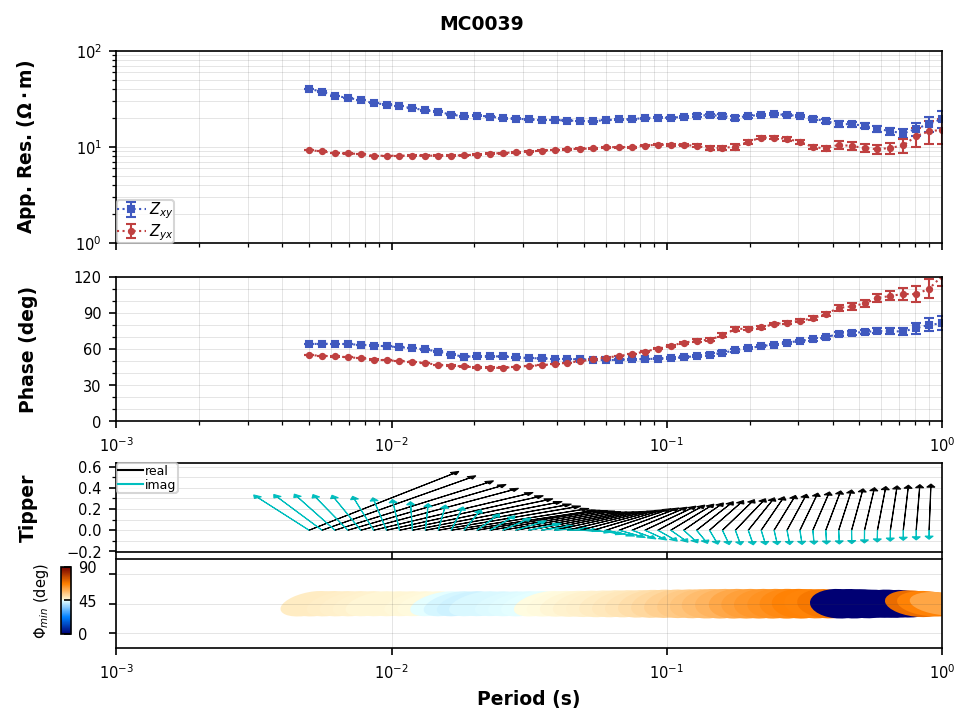

In [37]:
try:
    sondeo.plot_mt_response()
except:
    pass

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 3 · Extraer datos para la inversión</span></div>

In [61]:
# Extraer frecuencias, resistividad aparente y fase
frecuencias = np.array(sondeo.Z.frequency)   # Array de frecuencias (Hz)
rho_app     = np.array(sondeo.Z.res_xy)    # Resistividad aparente del det(Z) [Ω·m]
phase       = np.array(sondeo.Z.phase_xy)   # Fase del det(Z) [°]

print(f"   Frecuencias : {len(frecuencias)} valores  [{frecuencias.min():.3e} — {frecuencias.max():.3e}] Hz")
print(f"   ρ_app  media : {rho_app.mean():.2f} Ω·m")
print(f"   φ      media : {phase.mean():.2f}°")


   Frecuencias : 50 valores  [1.000e+00 — 1.995e+02] Hz
   ρ_app  media : 21.68 Ω·m
   φ      media : 61.09°


In [62]:
# Analizar los errores de los datos
# Los errores son esenciales para la inversión: definen el peso de cada dato.
error_rho   = sondeo.Z.res_error_xy    # Error absoluto en ρ_app
error_phase = sondeo.Z.phase_error_xy # Error absoluto en φ [°]

print("Estadísticas de error:")
print(f"   Error ρ_app — media: {error_rho.mean():.2f} Ω·m")
print(f"              — relativo: {(error_rho/rho_app).mean()*100:.1f} %")
print(f"   Error φ     — media: {error_phase.mean():.2f} °")


Estadísticas de error:
   Error ρ_app — media: 0.61 Ω·m
              — relativo: 3.3 %
   Error φ     — media: 0.94 °


In [63]:
# Construir el vector de datos observados dobs 
# Formato: [ρ₁, φ₁, ρ₂, φ₂, ..., ρₙ, φₙ]
# np.concatenate con un bucle garantiza el orden correcto de intercalado
dobs = np.empty((0,))
for r, p in zip(rho_app, phase):
    dobs = np.concatenate((dobs, [r, p]))

print(f"   Vector dobs construido: {len(dobs)} elementos ({len(frecuencias)} frecuencias × 2 tipos de dato)")
print(f"   Primeros 6 elementos: {dobs[:6]}")


   Vector dobs construido: 100 elementos (50 frecuencias × 2 tipos de dato)
   Primeros 6 elementos: [40.15425187 64.36056741 37.62494182 64.39189543 33.95784249 64.53021948]


### Visualizar profundidad de investigación alcanzada por el sondeo

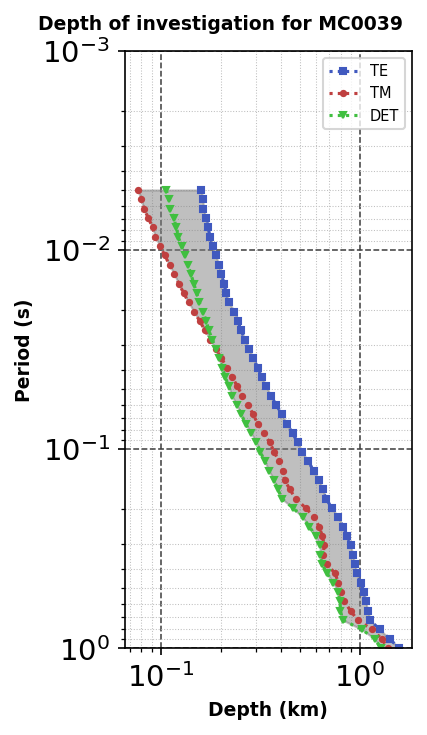

Plotting PlotPenetrationDepth1D

In [64]:
sondeo.plot_depth_of_penetration()

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 4 · Definir la malla 1D</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">La malla 1D es una columna de capas con espesores crecientes en profundidad. Los parámetros clave son:<br>• <b>dz</b>: espesor de la capa más somera (en metros).<br>• <b>n_layer</b>: número total de capas.<br>• <b>z_factor</b>: razón de crecimiento entre capas consecutivas (>1). Valores típicos: 1.5–2.0.<br>La <b>última capa es semi-infinita</b> (half-space) y su espesor no se incluye en <code>layer_thicknesses_inv</code>.</div>

In [65]:
# Modelo inicial
dz = 10 # Espesor de la primera capa (metros)
n_layer = 10 # Número total de capas (incluyendo el half-space)
z_factor = 1.7 # # Factor de crecimiento de espesores
layer_thicknesses_inv = dz*z_factor**np.arange(n_layer-1)[::-1] # espesores de las capas del modelo
print("El espesor total del modelo será:", layer_thicknesses_inv.sum(), "metros")

El espesor total del modelo será: 1679.8268070999998 metros


<div style="background:#eaf4fb;border-left:5px solid #2980B9;padding:10px 14px;border-radius:4px;margin:6px 0">💡 <b>Tip:</b> La profundidad total del modelo debe cubrir la profundidad máxima de investigación estimada en la celda anterior. Si es insuficiente, aumenta <code>n_layer</code> o <code>z_factor</code>.</div>

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 5 · Función de inversión</span></div>

### Arquitectura de una inversión en SimPEG

```
TensorMesh        ← Malla (capas y espesores)
    ↓
Survey            ← Geometría: fuentes (ondas planas) + receptores (ρ_a, φ)
    ↓
Simulation1DRecursive  ← Física: calcula d_pred dado m
    ↓
DataMisfit L2     ← φ_d = ‖W_d (d_obs - d_pred)‖²
    ↓
Regularization    ← φ_m = α_s‖m - m_ref‖² + α_z‖∇m‖²
    ↓
InexactGaussNewton← Algoritmo de optimización
    ↓
BaseInvProblem    ← Combina todo + gestiona β
    ↓
Directives        ← BetaEstimate, BetaSchedule, TargetMisfit, SaveOutput
    ↓
BaseInversion     ← Orquesta el loop iterativo
```

In [66]:
# Definir la función de inversión completa 
def run_fixed_layer_inversion(
    dobs,
    standard_deviation,
    rho_0,         
    rho_ref,
    maxIter=30,
    maxIterCG=30,
    alpha_s=1e-10,
    alpha_z=1,
    beta0_ratio=1,
    coolingFactor=2,
    coolingRate=1,
    chi_factor=1,
    use_irls=False,
    p_s=2,
    p_z=2
    
):
    # Malla
    mesh_inv = TensorMesh([(np.r_[layer_thicknesses_inv, layer_thicknesses_inv[-1]])], "N")

    # Survey
    receivers_list = [
        nsem.receivers.PointNaturalSource(component="app_res"),
        nsem.receivers.PointNaturalSource(component="phase"),
    ]

    source_list = []
    for freq in frecuencias:
        source_list.append(nsem.sources.Planewave(receivers_list, freq))

    survey = nsem.survey.Survey(source_list)

    sigma_map = maps.ExpMap(nP=len(layer_thicknesses_inv)+1)

    # Definir la simulación 
    simulation = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey, 
        sigmaMap=sigma_map,
        thicknesses=layer_thicknesses_inv,
    )
    
    # Definir los datos
    data_object = data.Data(survey, dobs=dobs, standard_deviation=standard_deviation)    
    
    # Modelo inicial
    m0 = np.ones(len(layer_thicknesses_inv)+1) * np.log(1./rho_0)
    
    # Modelo de referencia
    mref = np.ones(len(layer_thicknesses_inv)+1) * np.log(1./rho_ref)    

    #Definir el desajuste de los datos
    dmis = data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

    # Definir la regularización
    reg = regularization.Sparse(mesh_inv, alpha_s=alpha_s, alpha_x=alpha_z, reference_model=mref, mapping=maps.IdentityMap(mesh_inv))
    print (reg.alpha_s, reg.alpha_z)
    
    # Definir la optimización
    opt = optimization.InexactGaussNewton(maxIter=maxIter, maxIterCG=maxIterCG, tolG=1e-40, eps=1e-30)

    # Definir el problema inverso
    inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

    #######################################################################
    # Definir las directivas de inversión
    # ---------------------------
    #
    # Define un valor inicial para el parámetro de compensación beta
    starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)

    # Establece la tasa de reducción del parámetro de compensación beta
    beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
    save_dictionary = directives.SaveOutputDictEveryIteration()
    save_dictionary.outDict = {}
    
    # Configurar un criterio de parada para la inversión
    target_misfit = directives.TargetMisfit(chifact=chi_factor)
    precond = directives.UpdatePreconditioner()
    
    if use_irls:
        reg.norms = np.r_[p_s, p_z]
        reg.gradient_type = 'components'
        IRLS = directives.Update_IRLS(max_irls_iterations=40, minGNiter=1, f_min_change=1e-5)
        IRLS.coolEpsFact = 1.5
        precond = directives.UpdatePreconditioner()
        # Las directivas son definidas como una lista
        directives_list = [
            IRLS,
            starting_beta,
            save_dictionary,
            precond
        ]
    else:
        # Las directivas son definidas como una lista
        directives_list = [
            starting_beta,
            beta_schedule,
            target_misfit,
            save_dictionary
        ]

    #####################################################################
    # ---------------------
    # Combinar el problema inverso y las directivas
    inv = inversion.BaseInversion(inv_prob, directives_list)

    # Ejecutar la inversión
    recovered_model = inv.run(m0)    
    
    return recovered_model, save_dictionary.outDict

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 6 · Configurar y ejecutar la inversión</span></div>

### Guia de parametros de la inversion

#### Modelo inicial y malla 1D

| Parametro | Descripcion | Valor usado |
|-----------|-------------|-------------|
| `dz` | Espesor de la primera capa (mas somera) | 10 m |
| `n_layer` | Numero total de capas (incluye half-space) | 10 |
| `z_factor` | Factor de crecimiento de espesores entre capas | 1.7 |
| Espesor capa mas profunda | Calculado: `dz * z_factor^(n-2)` | 697.6 m |
| Profundidad total del modelo | Suma de espesores | 1679.8 m |
| `rho_0` | Resistividad del modelo inicial homogeneo | 100 ohm·m |
| `rho_ref` | Resistividad del modelo de referencia | 100 ohm·m |

#### Errores de los datos

| Parametro | Descripcion | Valor usado |
|-----------|-------------|-------------|
| `relative_error_rho` | Error relativo aplicado a la resistividad aparente | 8 % |
| `floor_phase` | Error minimo (piso) aplicado a la fase | 1.5 deg |

#### Optimizador — Inexact Gauss-Newton

| Parametro | Descripcion | Valor usado |
|-----------|-------------|-------------|
| `maxIter` | Maximo de iteraciones Gauss-Newton | 20 |
| `maxIterCG` | Maximo de iteraciones del solver CG interno | 30 |
| `tolG` | Tolerancia del gradiente para convergencia | 1e-40 |
| `eps` | Tolerancia numerica minima | 1e-30 |

#### Regularizacion Sparse

| Parametro | Descripcion | Valor usado |
|-----------|-------------|-------------|
| `alpha_s` | Peso de la pequenez (similaridad a m_ref) | 1e-5 |
| `alpha_z` | Peso de la suavidad vertical (gradiente) | 1 |
| `p_s` | Norma Lp para la pequenez (2=L2, 1=L1) | 2 |
| `p_z` | Norma Lp para la suavidad (2=L2, 1=L1) | 2 |

#### Directivas (control de beta)

| Parametro | Descripcion | Valor usado |
|-----------|-------------|-------------|
| `beta0_ratio` | Factor multiplicativo para el beta inicial | 1 |
| `coolingFactor` | Divisor de beta en cada ciclo de enfriamiento | 2 |
| `coolingRate` | Iteraciones GN entre cada reduccion de beta | 3 |
| `chi_factor` | Criterio de parada: phi_d <= chi_factor * N_datos | 1 |


## Definir los datos de inversión

In [67]:
# Definir los errores para la inversión
relative_error_rho = 0.08 # Error relativo de la resistividad
floor_phase = 1.5 # Error de la fase

rho_app = dobs.reshape((len(frecuencias), 2))[:,0] # Datos de resistividad
phase = dobs.reshape((len(frecuencias), 2))[:,1] # Datos de la fase

standard_deviation = np.c_[abs(rho_app)*relative_error_rho, np.ones(len(phase))*floor_phase].flatten() # Desviación estándar de los datos

rho_0 = 100 # modelo inicial
rho_ref = 100. # modelo de referencia

## Definir los parámetros de inversión

In [68]:
# Ejecutar la inversión 
# Ajusta los parámetros según los resultados de la curva de Tikhonov
recovered_model, output_dict = run_fixed_layer_inversion(
    dobs,
    standard_deviation,
    rho_0,
    rho_ref,
    maxIter=20, # máximas iteraciones
    maxIterCG=30,
    alpha_s=1e-5, # constante de escala para la pequeñez
    alpha_z=1, # constante de escala para la suavidad
    beta0_ratio=1, # valor inicial de beta
    coolingFactor=2, # disminución de beta
    coolingRate=3, # disminución de beta
    chi_factor=1, # criterio de parada
    p_s = 2, # norma para la pequeñez
    p_z = 2, # norma para la suavidad
)

1e-05 100.0

Running inversion with SimPEG v0.23.0

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DRecursive problem***
                        
model has any nan: 0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  9.61e+04  1.30e+05  0.00e+00  1.30e+05    1.12e+05      0              
   1  9.61e+04  2.02e+04  1.18e-02  2.14e+04    1.61e+04      0              
   2  9.61e+04  6.68e+03  4.13e-02  1.07e+04    1.92e+03      0   Skip BFGS  
   3  4.81e+04  6.08e+03  4.06e-02  8.03e+03    1.75e+03      0   Skip BFGS  
   4  4.81e+04  3.61e+03  7.25e-02  7.10e+03    7.69e+02      0              
   5  4.81e+04  3.20e+03  7.44e-02  6.78e+03    3.28e+02  

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 7 · Analizar convergencia (Curva de Tikhonov)</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">La <b>curva de Tikhonov</b> (o curva L) grafica φ<sub>m</sub> vs φ<sub>d</sub> para cada iteración de la inversión. Al inicio, β es grande → φ<sub>m</sub> es pequeño (modelo suave) pero φ<sub>d</sub> es grande (mal ajuste). A medida que β decrece, φ<sub>d</sub> disminuye (mejor ajuste) pero φ<sub>m</sub> aumenta (modelo más complejo). La solución óptima está en el 'codo' de la curva, donde φ<sub>d</sub> ≈ N (número de datos).</div>

In [69]:
# Evoluación de la métrica del desajuste de los datos y el desajuste del modelo durante las iteraciones
target_misfit = dobs.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

## Curva de Tikhonov

In [70]:
matplotlib.rcParams['font.size'] = 14

def tikhonov_curve(iteration, scale='log'):
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.plot(phi_ms, phi_ds, label="Curva de Tikhonov")
    
    point = ax.plot(phi_ms[iteration-1], phi_ds[iteration-1], 'ro', label=f'Iteración={iteration}, Beta={betas[iteration-1]:.1e}')
    
    ax.set_xlabel("$\phi_m$")
    ax.set_ylabel("$\phi_d$")
    
    if scale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')
        
    xlim = ax.get_xlim()
    ax.plot(xlim, np.ones(2) * target_misfit, '--')

    ax.legend(loc='best', fontsize=12)
    
    ax.set_xlim(xlim)
    plt.show()

In [71]:
from ipywidgets import interact, widgets
Q_iter = interact(
    tikhonov_curve, 
    iteration=widgets.IntSlider(min=1, max=int(n_iteration), value=n_iteration),
    scale=widgets.RadioButtons(options=['linear', 'log'])
)

interactive(children=(IntSlider(value=20, description='iteration', max=20, min=1), RadioButtons(description='s…

<div style="background:#eaf4fb;border-left:5px solid #2980B9;padding:10px 14px;border-radius:4px;margin:6px 0">💡 <b>Tip:</b> Usa el slider para seleccionar la iteración donde la curva de Tikhonov cruza la línea punteada (φ_d ≈ N). Esa es la iteración que usarás para visualizar el modelo final en la siguiente sección.</div>

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 8 · Visualizar el modelo de resistividad invertido</span></div>

In [72]:
import os

In [73]:
# Definir el nombre de la carpeta y el archivo
folder_path = 'Modelos1D'  # Carpeta donde quieres guardar la imagen
filename = "Modelo de resistividad 1D.png"  # Nombre del archivo

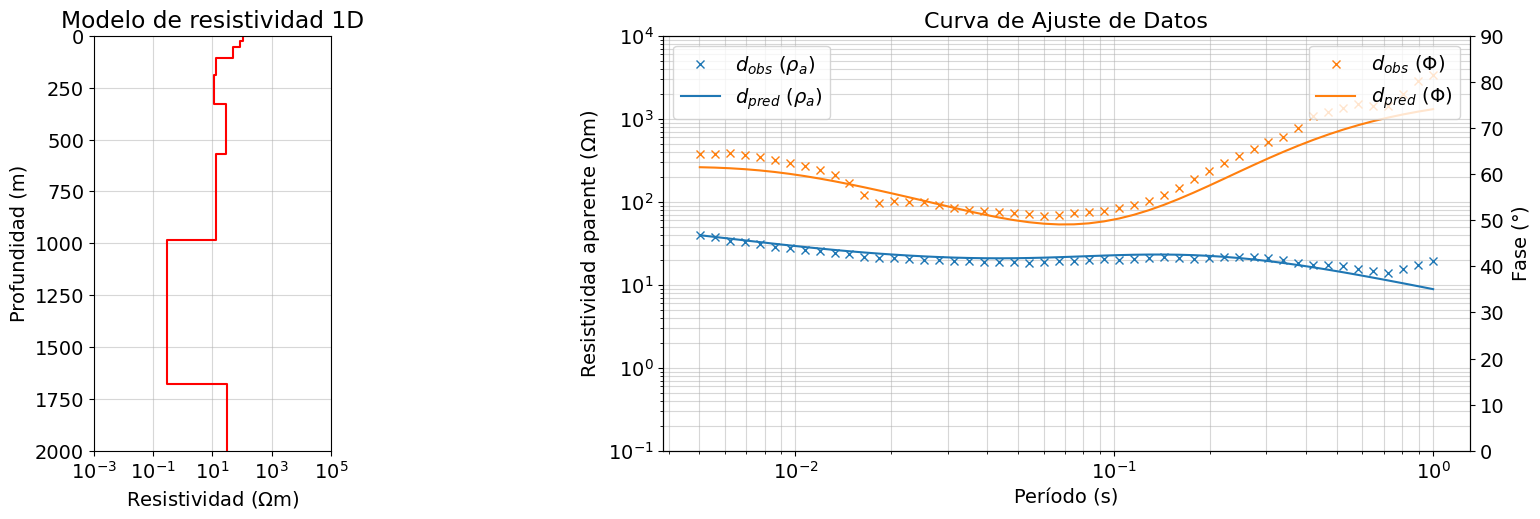

In [83]:
iteration = Q_iter.widget.kwargs['iteration']
dpred = output_dict[iteration]['dpred']
m = output_dict[iteration]['m']

# Modelo de resistividad 1D y Curvas de ajuste de datos 
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 5, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
plot_1d_layer_model(
    layer_thicknesses_inv[::-1],
    (1./(np.exp(m)))[::-1],
    ax=ax0,
    color="red", **{'linestyle':'-'},
)
ax0.set_title("Modelo de resistividad 1D")
ax0.set_xlabel("Resistividad ($\Omega$m)")
ax0.set_ylabel("Profundidad (m)")  # Título del eje Y cambiado aquí
ax0.grid(True, which='both', alpha=0.5)

ax = fig.add_subplot(gs[0, 2:])
ax.loglog(1./frecuencias, dobs.reshape((len(frecuencias), 2))[:,0], 'x', color='C0', label=r'$d_{obs}$ ($\rho_{a}$)')
ax.loglog(1./frecuencias, dpred.reshape((len(frecuencias), 2))[:,0], color='C0', label=r'$d_{pred}$ ($\rho_{a}$)')

plt.title("Curva de Ajuste de Datos", fontsize=16)  # Título global para toda la figura

ax_1 = ax.twinx()
ax_1.plot(1./frecuencias, dobs.reshape((len(frecuencias), 2))[:,1], 'x', color='C1', label=r'$d_{obs}$ ($\Phi$)')
ax_1.plot(1./frecuencias, dpred.reshape((len(frecuencias), 2))[:,1], color='C1', label=r'$d_{pred}$ ($\Phi$)')
ax.set_xlabel("Período (s)")
ax.grid(True, which='both', alpha=0.5)
ax.set_ylabel("Resistividad aparente ($\Omega$m)")
ax_1.set_ylabel("Fase ($\degree$)")
ax.legend(loc=2)
ax_1.legend(loc=1)
ax.set_ylim([10**-1, 10**4])
ax_1.set_ylim(0, 90)    
ax0.set_xlim([10**-3, 10**5])
ax0.set_ylim(2000, 0)

fig_path = os.path.join(folder_path, filename)
plt.savefig(fig_path, dpi=300, bbox_inches='tight', format="png")

plt.show()

## Error RMSE

In [84]:
residual = dobs - dpred
rmse = np.sqrt(np.mean(residual**2))
print("RMSE =", rmse)

RMSE = 2.9223772516600466


## Error relativo 

In [85]:
relative_error = 100 * np.linalg.norm(dobs - dpred) / np.linalg.norm(dobs)
print("Error relativo (%) =", relative_error)

Error relativo (%) = 6.29664426203671


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 9 · Guardar el modelo invertido</span></div>

In [86]:
import os

resistividad = (1./(np.exp(m)))[::-1]
espesores = layer_thicknesses_inv[::-1]

carpeta = "Modelos1D"
os.makedirs(carpeta, exist_ok=True)

ruta_archivo = os.path.join(carpeta, "P.npz")
np.savez(ruta_archivo, espesores=espesores, resistividad=resistividad)

print(f"Datos guardados en {ruta_archivo}")

Datos guardados en Modelos1D\P.npz
